In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, classification_report, f1_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split, GridSearchCV
from scipy.stats import randint
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.metrics import roc_curve, RocCurveDisplay, auc
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.model_selection import cross_val_score
from matplotlib.patches import Patch
import time


In [48]:
df = pd.read_csv("weather_classification_data.csv")
df['Was_Rain'] = 0
df.loc[df['Weather Type'] == 'Rainy' , 'Was_Rain'] = 1

In [50]:
df = df[ (df["Temperature"] >= -20) &
    (df["Temperature"] <= 55) & (df["Atmospheric Pressure"] <= 1085) & (df["Atmospheric Pressure"] >= 870)]

In [52]:
df = df[ df['Humidity'] <= 100]

In [54]:
df = df[df['Precipitation (%)'] <= 100]

In [56]:
df["Cloud Cover"] = pd.Categorical(
    df["Cloud Cover"],
    categories=["clear", "partly cloudy", "cloudy", "overcast"],
    ordered=True
)

df["cloud_cover"] = df["Cloud Cover"].cat.codes
df.drop(columns = ["Cloud Cover", "Weather Type"] , inplace = True)

In [58]:
df = pd.get_dummies(df, columns=["Season", "Location"], dtype=int, drop_first = True)

In [60]:
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Was_Rain,cloud_cover,Season_Spring,Season_Summer,Season_Winter,Location_inland,Location_mountain
0,14.0,73,9.5,82.0,1010.82,2,3.5,1,1,0,0,1,1,0
1,39.0,96,8.5,71.0,1011.43,7,10.0,0,1,1,0,0,1,0
2,30.0,64,7.0,16.0,1018.72,5,5.5,0,0,1,0,0,0,1
3,38.0,83,1.5,82.0,1026.25,7,1.0,0,0,1,0,0,0,0
4,27.0,74,17.0,66.0,990.67,1,2.5,1,3,0,0,1,0,1


In [62]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Was_Rain,cloud_cover,Season_Spring,Season_Summer,Season_Winter,Location_inland,Location_mountain
count,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000
mean,18.224426,67.703149,9.394213,50.601957,1004.551123,3.623234,5.333787,0.250468,1.792511,0.193957,0.185702,0.435234,0.365277,0.368936
std,15.361547,19.096377,6.336468,31.147812,19.954450,3.605576,3.060403,0.433301,1.196718,0.395413,0.388883,0.495809,0.481528,0.482537
min,-20.000000,20.000000,0.000000,0.000000,870.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,18.000000,994.912500,1.000000,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,21.000000,69.000000,8.500000,54.000000,1007.230000,2.000000,5.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,30.000000,82.000000,13.000000,79.000000,1016.210000,6.000000,7.500000,1.000000,3.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,55.000000,100.000000,48.500000,100.000000,1084.820000,14.000000,20.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Training / Test Data Split

In [65]:
X = df.drop(columns=['Was_Rain'])
y = df['Was_Rain']

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = True, random_state = 28)

In [69]:
len(X_train), len(X_test)

(9400, 2350)

In [71]:
len(y_train), len(y_test)

(9400, 2350)

In [73]:
from sklearn.model_selection import StratifiedKFold

k = 5
cv = StratifiedKFold(
    n_splits=k,
    shuffle=True,
    random_state=28
)

## Random Forest

The RandomForestClassifier has the default number of trees set to 100. 

I want to tune the depth of the tree so its optimal but not too complex to visualise. Will do this using cross validation.

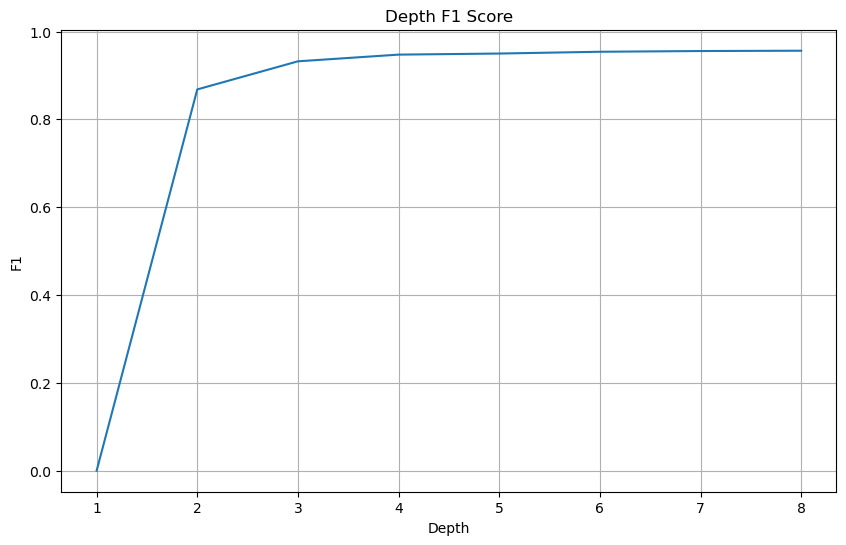

[1, 2, 3, 4, 5, 6, 7, 8]
[0.0, 0.868200799247058, 0.9321996782326696, 0.9474446865415687, 0.9499046881497988, 0.953955545041428, 0.9556123573299748, 0.9563191878204818]
[0.0, 0.015098084219053313, 0.00751832364105278, 0.006750752053630818, 0.007394235287862317, 0.006620297057331401, 0.005216355690510046, 0.006947230031020938]


In [85]:
depths = [1,2,3,4,5,6,7,8]
scores_cv = []
scores_std = []


for i in depths:
    random_forest = RandomForestClassifier(max_depth=i, max_features = 'sqrt', random_state=28)
    cv_score = cross_val_score(random_forest, X_train, y_train, cv=cv, scoring = 'f1').mean()
    std_score = cross_val_score(random_forest, X_train, y_train, cv=cv, scoring = 'f1').std()
    scores_cv.append(cv_score)
    scores_std.append(std_score)

plt.figure(figsize=(10,6))
plt.plot(depths, scores_cv)
plt.title("Depth F1 Score")
plt.ylabel("F1")
plt.xlabel("Depth")
plt.grid()
plt.show()

print(depths)
print(scores_cv)
print(scores_std)

The highest F1 Score was for 8, however 8 is still quite a complex tree. Therefore will compare the difference between the mean F1 score of depth 5 and 8 to see if they're comparable.

In [87]:
0.9499046881497988 - 0.9563191878204818

-0.0064144996706829716

Now comparing to the standard deviations at each depth (0.0074 , 0.0069), since the standard deviation are larger than the mean difference, 5 could be chosen instead of 8 for simplicity.

Now fitting the model with max depth 5.

In [95]:
random_forest = RandomForestClassifier(max_depth = 5, max_features = 'sqrt', random_state = 28)

In [98]:
start = time.time()
random_forest.fit(X_train, y_train)
end = time.time()
print(f"Training time: {end - start:.2f} seconds")


Training time: 0.36 seconds


You are able to see the feature importances within the random forest, so will plot them for information on what the fitted model is like.

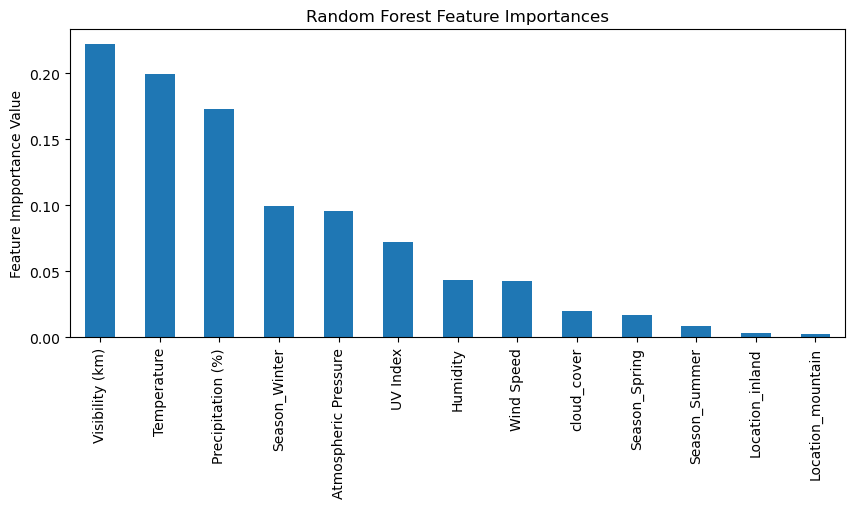

In [100]:
importances = random_forest.feature_importances_
feature_names = X_train.columns
series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,4))
series.plot(kind='bar')
plt.title("Random Forest Feature Importances")
plt.ylabel("Feature Impportance Value")
plt.show()

Now applying 5-fold cross validation on the training set to see how the algorithm is performing. 

In [103]:
results_acc_rf = cross_val_score(random_forest, X_train, y_train, cv=cv, scoring = 'accuracy')
results_pre_rf = cross_val_score(random_forest, X_train, y_train, cv=cv, scoring = 'precision')
results_rec_rf = cross_val_score(random_forest, X_train, y_train, cv=cv, scoring = 'recall')
results_f1_rf = cross_val_score(random_forest, X_train, y_train, cv=cv, scoring = 'f1')

print("Mean CV accuracy:", results_acc_rf.mean(), "+/-", results_acc_rf.std())
print("Mean CV precision:", results_pre_rf.mean(), "+/-", results_pre_rf.std())
print("Mean CV recall:", results_rec_rf.mean(), "+/-", results_rec_rf.std())
print("Mean CV F1:", results_f1_rf.mean(), "+/-", results_f1_rf.std())

Mean CV accuracy: 0.9753191489361702 +/- 0.003601342740385263
Mean CV precision: 0.9599431957275566 +/- 0.009309564014582182
Mean CV recall: 0.94017094017094 +/- 0.010726410596590715
Mean CV F1: 0.9499046881497988 +/- 0.007394235287862317


Now going to fit an ROC Curve to have a visual idea of performance and to find the optimal threshold to use. Currently the threshold is 0.5, so if 51 out of the 100 trees predict rain, then rain will be the output. For unbalanced data, this isnt always the best threshold. Will use the Youden Statistic to calculate the optimal threshold for each fold, and then find the average to use in the analysis.

Fold 0 Best Threshold: 0.6495
Fold 1 Best Threshold: 0.3285
Fold 2 Best Threshold: 0.5498
Fold 3 Best Threshold: 0.2004
Fold 4 Best Threshold: 0.4933
0.44431302055894595


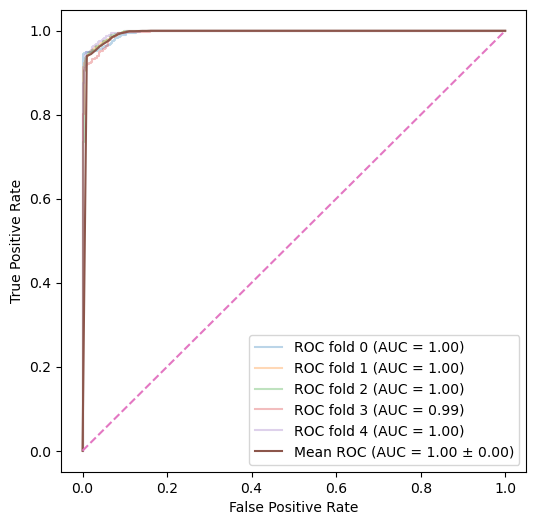

In [110]:
cv_results = cross_validate(
    random_forest, X_train, y_train, cv=cv, return_estimator=True, return_indices=True)

tprs = []
aucs = []
best_thresholds = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(6, 6))

for i, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train)):
    model = cv_results["estimator"][i]
    probas = model.predict_proba(X_train.iloc[test_idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_train.iloc[test_idx], probas)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    aucs.append(auc(fpr, tpr))
    fpr, tpr, thresholds = roc_curve(y_train.iloc[test_idx], probas)

    # Calculate Youdens Statistic
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]
    best_thresholds.append(best_threshold)

    print(f"Fold {i} Best Threshold: {best_threshold:.4f}")

    plt.plot(fpr, tpr, alpha=0.3, label=f"ROC fold {i} (AUC = {aucs[i]:.2f})")

print(np.mean(best_thresholds))
optimal_threshold = np.mean(best_thresholds)
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)
rf_aucs = aucs

plt.plot(mean_fpr, mean_tpr, label=f"Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Now doing final test on holdout data. Going to compare the default 0.5 threshold with the optimal threshold found earlier. First looking at threshold = 0.5

In [112]:
start = time.time()
y_pred_rf = random_forest.predict(X_test)
end = time.time()
print(f"Prediction time: {end - start:.2f} seconds")


print(classification_report(y_test, y_pred_rf))

Prediction time: 0.03 seconds
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1747
           1       0.96      0.95      0.95       603

    accuracy                           0.98      2350
   macro avg       0.97      0.97      0.97      2350
weighted avg       0.98      0.98      0.98      2350



Now looking at results with the "optimal threshold". Recall for Class 1 actually stayed the same at 95%, and the precision decreased due to rain being predicted more at this lower threshold. This suggests that in this instance the 'optimal threshold' is actually overfitting to the CV dataset, and the default 0.5 threshold is actually well suited for this data.

In [114]:
test_probabilities = random_forest.predict_proba(X_test)[:, 1]
y_pred_rf_opt = (test_probabilities >= optimal_threshold).astype(int)

print(classification_report(y_test, y_pred_rf_opt))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1747
           1       0.95      0.95      0.95       603

    accuracy                           0.97      2350
   macro avg       0.97      0.96      0.96      2350
weighted avg       0.97      0.97      0.97      2350



## Logistic Regression

In [118]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

For logistic regression, need to scale the data points in order to get better results. First going to fine tune the hyper parameter C. The default is 1, and I found that 10 is the optimal C very slightly.

In [123]:
Cs = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
scores = []

for i in Cs:
    logreg_model = make_pipeline(StandardScaler(), LogisticRegression(C = i, random_state=28, max_iter=5000)
)
    cv_score = cross_val_score(logreg_model, X_train, y_train, cv=cv, scoring = 'f1').mean()
    scores.append(cv_score)

scores = pd.DataFrame(scores,  Cs)
print(scores)

                 0
0.001     0.686224
0.010     0.814232
0.100     0.825000
1.000     0.826747
10.000    0.826828
100.000   0.826828
1000.000  0.826828


Now fitting model with C = 10

In [128]:
logreg_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=28, max_iter=5000, C = 10)
)


start = time.time()
logreg_model.fit(X_train, y_train)
end = time.time()
print(f"Training time: {end - start:.2f} seconds")


Training time: 0.04 seconds


Logistic regression finds the mles of beta coefficients within its equation. Will now find the value of each beta so I can compare with the random forest importances in the report.

In [43]:
print('Beta Coefficients:' ,logreg_model.named_steps['logisticregression'].coef_)
print('Intercept:' , logreg_model.named_steps['logisticregression'].intercept_)

Beta Coefficients: [[ 1.46435805  0.1257121   0.38934656  1.56619767 -0.09519071 -0.8430455
  -1.03592869  0.63876702  0.02784668  0.03969285 -0.96518645 -0.43358811
  -0.47862095]]
Intercept: [-2.40332481]


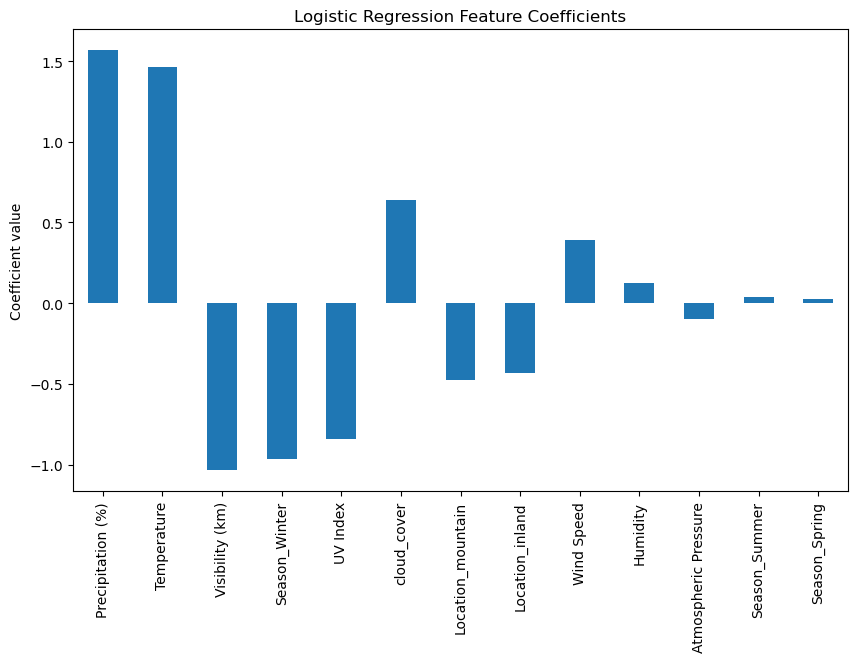

In [131]:
lr_step = logreg_model.named_steps['logisticregression']

coefficients = pd.Series(lr_step.coef_[0], index=X.columns)

coefficients_sorted = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)


plt.figure(figsize=(10,6))
coefficients_sorted.plot(kind='bar')
plt.title("Logistic Regression Feature Coefficients")
plt.ylabel("Coefficient value")
plt.show()

Now doing 5-fold cross validation focusing on the key metrics, so I can compare mean and s.d

In [134]:
from sklearn.model_selection import cross_val_score

results_acc_logreg = cross_val_score(logreg_model, X_train, y_train, cv=cv, scoring = 'accuracy')
results_pre_logreg = cross_val_score(logreg_model, X_train, y_train, cv=cv, scoring = 'precision')
results_rec_logreg = cross_val_score(logreg_model, X_train, y_train, cv=cv, scoring = 'recall')
results_f1_logreg = cross_val_score(logreg_model, X_train, y_train, cv=cv, scoring = 'f1')

print("Mean CV accuracy:", results_acc_logreg.mean(), "+/-", results_acc_logreg.std())
print("Mean CV precision:", results_pre_logreg.mean(), "+/-", results_pre_logreg.std())
print("Mean CV recall:", results_rec_logreg.mean(), "+/-", results_rec_logreg.std())
print("Mean CV F1:", results_f1_logreg.mean(), "+/-", results_f1_logreg.std())

Mean CV accuracy: 0.9184042553191489 +/- 0.005174632556176725
Mean CV precision: 0.8764157508321343 +/- 0.01444740514568226
Mean CV recall: 0.782905982905983 +/- 0.019235516982781035
Mean CV F1: 0.8268283165131074 +/- 0.011871920587779168


Again finding optimal cross hold and looking at AUC.

Fold 0 Best Threshold: 0.2261
Fold 1 Best Threshold: 0.3380
Fold 2 Best Threshold: 0.2779
Fold 3 Best Threshold: 0.3744
Fold 4 Best Threshold: 0.3108
0.30545723037367906


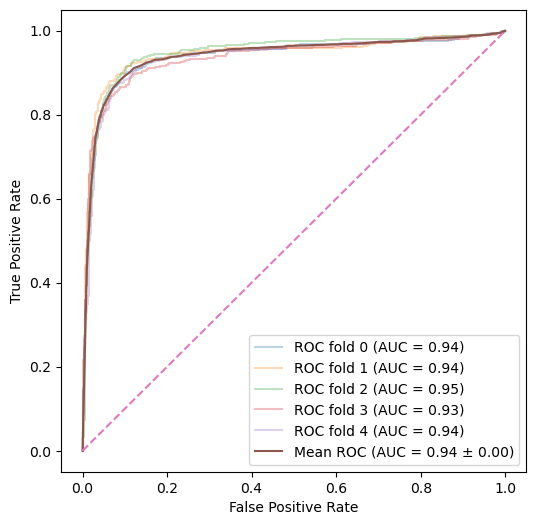

In [137]:
cv_results = cross_validate(
    logreg_model, X_train, y_train, cv=cv, return_estimator=True, return_indices=True)

tprs = []
aucs = []
best_thresholds = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(6, 6))

for i, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train)):
    model = cv_results["estimator"][i]
    probas = model.predict_proba(X_train.iloc[test_idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_train.iloc[test_idx], probas)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    aucs.append(auc(fpr, tpr))
    fpr, tpr, thresholds = roc_curve(y_train.iloc[test_idx], probas)

    #Youden Statistic
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]
    best_thresholds.append(best_threshold)

    print(f"Fold {i} Best Threshold: {best_threshold:.4f}")

    plt.plot(fpr, tpr, alpha=0.3, label=f"ROC fold {i} (AUC = {aucs[i]:.2f})")
    
optimal_threshold = np.mean(best_thresholds)
print(optimal_threshold)
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)
logreg_aucs = aucs

plt.plot(mean_fpr, mean_tpr, label=f"Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Finally, applying model to the unseen test data for both the default and optimal threshold. 

In [139]:
start = time.time()
y_pred_lr = logreg_model.predict(X_test)
end = time.time()
print(f"Prediction time: {end - start:.2f} seconds")
print(classification_report(y_test, y_pred_lr))

Prediction time: 0.01 seconds
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1747
           1       0.86      0.75      0.80       603

    accuracy                           0.90      2350
   macro avg       0.89      0.85      0.87      2350
weighted avg       0.90      0.90      0.90      2350



In [141]:
test_probabilities = logreg_model.predict_proba(X_test)[:, 1]
y_pred_lr_opt = (test_probabilities >= optimal_threshold).astype(int)

print(classification_report(y_test, y_pred_lr_opt))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93      1747
           1       0.77      0.86      0.81       603

    accuracy                           0.90      2350
   macro avg       0.86      0.89      0.87      2350
weighted avg       0.90      0.90      0.90      2350



# Neural Network

In [143]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler


For Neural Network, need to select the best hidden layer structure. Using cross validation again wrt F1 Score. (26, 13, 6) was the best performing.

In [145]:
layer_options = [ (6,), (13,), (26,), (13, 6), (26, 13), (26, 13, 6)]
cv_scores = []

for i in layer_options:
    mlp = make_pipeline( StandardScaler(), MLPClassifier(hidden_layer_sizes= i, activation='relu', solver='sgd', max_iter=1000,random_state=28
))
    scores = cross_val_score(mlp, X_train, y_train, cv=cv, scoring='f1')  
    cv_scores.append(scores.mean())

df_results = pd.DataFrame({
    'Hidden Layer Structure': [str(x) for x in layer_options],
    'F1': [round(x, 4) for x in cv_scores]
})
print(df_results)

  Hidden Layer Structure      F1
0                   (6,)  0.9166
1                  (13,)  0.9210
2                  (26,)  0.9227
3                (13, 6)  0.9325
4               (26, 13)  0.9363
5            (26, 13, 6)  0.9425


Now fitting the model, scaling first. Chose to have solver as sgd since it fits with the mathematical background of my report.

In [151]:
mlp = make_pipeline( StandardScaler(), MLPClassifier(hidden_layer_sizes=(26,13, 6), activation='relu', 
                                                     solver='sgd', max_iter=1000, random_state=28))

start = time.time()
mlp.fit(X_train, y_train)
end = time.time()

print(f"Training time: {end - start:.2f} seconds")

Training time: 3.62 seconds


Cross-validating again to compare metric performance across folds.

In [154]:
results_acc_nn = cross_val_score(mlp, X_train, y_train, cv=cv, scoring = 'accuracy')
results_pre_nn = cross_val_score(mlp, X_train, y_train, cv=cv, scoring = 'precision')
results_rec_nn = cross_val_score(mlp, X_train, y_train, cv=cv, scoring = 'recall')
results_f1_nn = cross_val_score(mlp, X_train, y_train, cv=cv, scoring = 'f1')

print("Mean CV accuracy:", results_acc_nn.mean(), "+/-", results_acc_nn.std())
print("Mean CV precision:", results_pre_nn.mean(), "+/-", results_pre_nn.std())
print("Mean CV recall:", results_rec_nn.mean(), "+/-", results_rec_nn.std())
print("Mean CV F1:", results_f1_nn.mean(), "+/-", results_f1_nn.std())

Mean CV accuracy: 0.9718085106382979 +/- 0.0044248158176777505
Mean CV precision: 0.9576690355144434 +/- 0.009372425184376608
Mean CV recall: 0.9277777777777777 +/- 0.009782498412187684
Mean CV F1: 0.9424752669111818 +/- 0.009038330462848666


Finding optimal threshold and AUC.

Fold 0 Best Threshold: 0.3470
Fold 1 Best Threshold: 0.4174
Fold 2 Best Threshold: 0.1591
Fold 3 Best Threshold: 0.2191
Fold 4 Best Threshold: 0.1871
0.2659333270222634


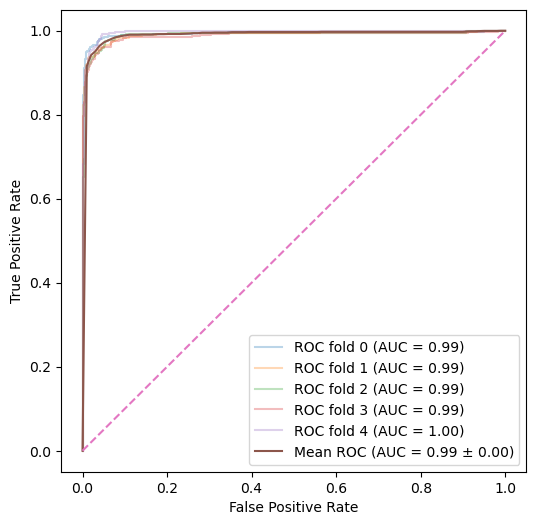

In [158]:
cv_results = cross_validate(
    mlp, X_train, y_train, cv=cv, return_estimator=True, return_indices=True)

tprs = []
aucs = []
best_thresholds = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(6, 6))

for i, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train)):
    model = cv_results["estimator"][i]
    probas = model.predict_proba(X_train.iloc[test_idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_train.iloc[test_idx], probas)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    aucs.append(auc(fpr, tpr))
    # Inside your for loop:
    fpr, tpr, thresholds = roc_curve(y_train.iloc[test_idx], probas)

    # Calculate Youden's J-Statistic
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]
    best_thresholds.append(best_threshold)

    print(f"Fold {i} Best Threshold: {best_threshold:.4f}")

    plt.plot(fpr, tpr, alpha=0.3, label=f"ROC fold {i} (AUC = {aucs[i]:.2f})")
    
optimal_threshold = np.mean(best_thresholds)
print(optimal_threshold)
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)
nn_aucs = aucs

plt.plot(mean_fpr, mean_tpr, label=f"Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Now making predictions with both 0.5 thresholds and the optimal threshold.

In [161]:
start = time.time()
y_pred_nn = mlp.predict(X_test)
end = time.time()
print(f"Prediction time: {end - start:.2f} seconds")


print(classification_report(y_test, y_pred_nn))


Prediction time: 0.04 seconds
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1747
           1       0.95      0.94      0.94       603

    accuracy                           0.97      2350
   macro avg       0.96      0.96      0.96      2350
weighted avg       0.97      0.97      0.97      2350



In [163]:
test_probabilities = mlp.predict_proba(X_test)[:, 1]
y_pred_nn_opt = (test_probabilities >= optimal_threshold).astype(int)

print(classification_report(y_test, y_pred_nn_opt))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1747
           1       0.88      0.96      0.92       603

    accuracy                           0.96      2350
   macro avg       0.93      0.96      0.94      2350
weighted avg       0.96      0.96      0.96      2350




# K Nearest Neighbours

In [165]:
from sklearn.neighbors import KNeighborsClassifier

With K-Nearest Neighbours, we can decide what k should be. Therefore in order to have the best performing model possible, going to see how k affects F1 Score before deciding on the final k.

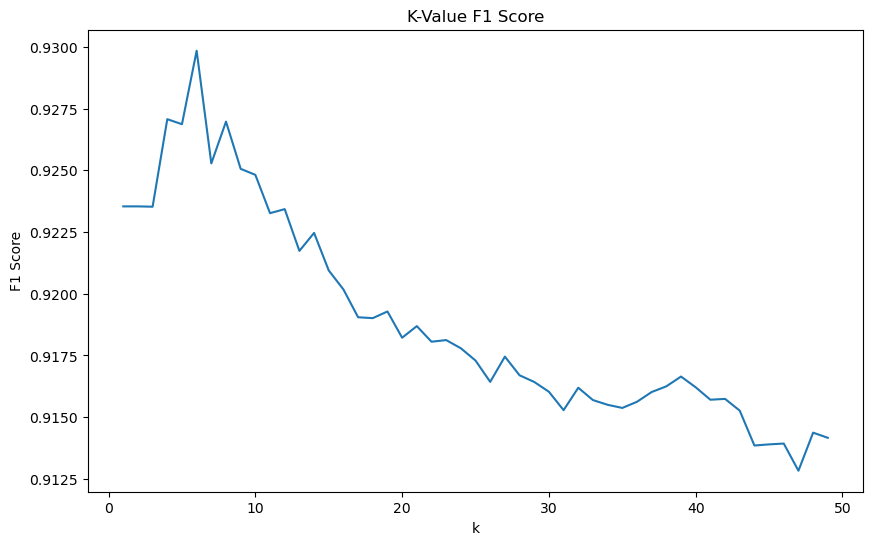

Optimal k: 6


In [168]:
k_values = range(1, 50)
cv_scores = []

for k in k_values:
    model_knn = make_pipeline( StandardScaler(), KNeighborsClassifier(n_neighbors=k, weights = 'distance') )
    scores = cross_val_score(model_knn, X_train, y_train, cv=cv, scoring='f1')  
    cv_scores.append(scores.mean())

plt.figure(figsize=(10,6))
plt.plot(k_values, cv_scores)
plt.title("K-Value F1 Score")
plt.ylabel("F1 Score")
plt.xlabel("k")
plt.show()


optimal_k = k_values[np.argmax(cv_scores)]
print("Optimal k:", optimal_k)

Fitting the model with k =6. 

In [172]:
model_knn = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors = 6, weights='distance') )

start = time.time()
model_knn.fit(X_train, y_train)
end = time.time()
print(f"Training time: {end - start:.2f} seconds")


Training time: 0.02 seconds


Calculating metric performance across 5 folds.

In [174]:
results_acc_knn = cross_val_score(model_knn, X_train, y_train, cv=cv, scoring = 'accuracy')
results_pre_knn = cross_val_score(model_knn, X_train, y_train, cv=cv, scoring = 'precision')
results_rec_knn = cross_val_score(model_knn, X_train, y_train, cv=cv, scoring = 'recall')
results_f1_knn = cross_val_score(model_knn, X_train, y_train, cv=cv, scoring = 'f1')

print("Mean CV accuracy:", results_acc_knn.mean(), "+/-", results_acc_knn.std())
print("Mean CV precision:", results_pre_knn.mean(), "+/-", results_pre_knn.std())
print("Mean CV recall:", results_rec_knn.mean(), "+/-", results_rec_knn.std())
print("Mean CV F1:", results_f1_knn.mean(), "+/-", results_f1_knn.std())

Mean CV accuracy: 0.9653191489361701 +/- 0.001695465686224381
Mean CV precision: 0.9363284594933157 +/- 0.002755346208737978
Mean CV recall: 0.9235042735042734 +/- 0.008264563934108444
Mean CV F1: 0.9298456054076988 +/- 0.0037327261136226616


Finding the optimal threshold and AUC.

Fold 0 Best Threshold: 0.4858
Fold 1 Best Threshold: 0.1571
Fold 2 Best Threshold: 0.3199
Fold 3 Best Threshold: 0.1754
Fold 4 Best Threshold: 0.2991
0.2874443922248055


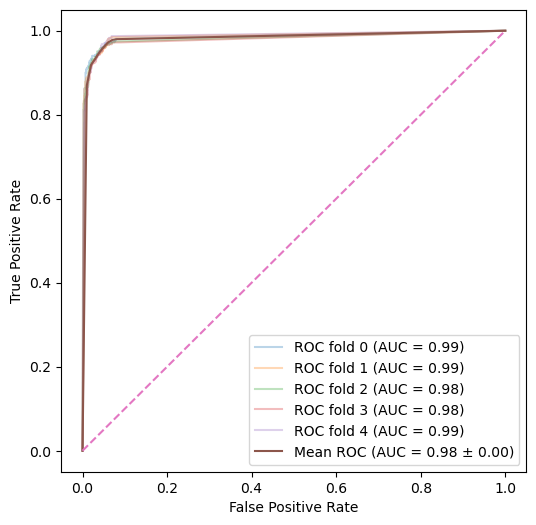

In [177]:
cv_results = cross_validate(
    model_knn, X_train, y_train, cv=cv, return_estimator=True, return_indices=True)

tprs = []
aucs = []
best_thresholds = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(6, 6))

for i, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train)):
    model = cv_results["estimator"][i]
    probas = model.predict_proba(X_train.iloc[test_idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_train.iloc[test_idx], probas)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    aucs.append(auc(fpr, tpr))
    # Inside your for loop:
    fpr, tpr, thresholds = roc_curve(y_train.iloc[test_idx], probas)

    # Calculate Youden's J-Statistic
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]
    best_thresholds.append(best_threshold)

    print(f"Fold {i} Best Threshold: {best_threshold:.4f}")

    plt.plot(fpr, tpr, alpha=0.3, label=f"ROC fold {i} (AUC = {aucs[i]:.2f})")

optimal_threshold = np.mean(best_thresholds)
print(optimal_threshold)
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)
knn_aucs = aucs

plt.plot(mean_fpr, mean_tpr, label=f"Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Performing hold-out test using 0.5 threshold and the optimal threshold.

In [180]:
start = time.time()
y_pred_knn = model_knn.predict(X_test)
end = time.time()
print(f"Prediction time: {end - start:.2f} seconds")


Prediction time: 0.12 seconds


In [182]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1747
           1       0.93      0.92      0.92       603

    accuracy                           0.96      2350
   macro avg       0.95      0.95      0.95      2350
weighted avg       0.96      0.96      0.96      2350



In [184]:
test_probabilities = model_knn.predict_proba(X_test)[:, 1]
optimal_threshold
y_pred_knn_opt = (test_probabilities >= optimal_threshold).astype(int)

print(classification_report(y_test, y_pred_knn_opt))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1747
           1       0.87      0.96      0.91       603

    accuracy                           0.95      2350
   macro avg       0.93      0.95      0.94      2350
weighted avg       0.95      0.95      0.95      2350



## Support Vector Machines

In [186]:
from sklearn.svm import SVC

There are 4 different kernel functions that can be used for SVM. They are linear, polynomial, rbf and sigmoid. Will use rbf. To do this will have to scale first, else performance can be bad.

In [188]:
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__kernel': ['linear', 'rbf'],
    'svc__gamma': ['scale', 'auto']
}

svm = make_pipeline(StandardScaler(),SVC())

grid_search = GridSearchCV(svm, param_grid, cv=cv, scoring='f1')


grid_search.fit(X_train, y_train)


print(f"Best params: {grid_search.best_params_}")

Best params: {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}


Fitting model with the optimal parameter settings.

In [192]:
model_svm = make_pipeline(StandardScaler(), SVC(kernel='rbf', C = 1, gamma = 'scale', probability = True, random_state = 28))


Cross-validation of performance across 5 folds.

In [195]:
results_acc_svm = cross_val_score(model_svm, X_train, y_train, cv=cv, scoring = 'accuracy')
results_pre_svm = cross_val_score(model_svm, X_train, y_train, cv=cv, scoring = 'precision')
results_rec_svm = cross_val_score(model_svm, X_train, y_train, cv=cv, scoring = 'recall')
results_f1_svm = cross_val_score(model_svm, X_train, y_train, cv=cv, scoring = 'f1')

print("Mean CV accuracy:", results_acc_svm.mean(), "+/-", results_acc_svm.std())
print("Mean CV precision:", results_pre_svm.mean(), "+/-", results_pre_svm.std())
print("Mean CV recall:", results_rec_svm.mean(), "+/-", results_rec_svm.std())
print("Mean CV F1:", results_f1_svm.mean(), "+/-", results_f1_svm.std())

Mean CV accuracy: 0.9740425531914895 +/- 0.003251214210624711
Mean CV precision: 0.9645991393626783 +/- 0.00916524293139066
Mean CV recall: 0.9299145299145298 +/- 0.0063959955329469164
Mean CV F1: 0.9469200138016187 +/- 0.006560435513884139


Finding the optimal threshold and AUC

Fold 0 Best Threshold: 0.2279
Fold 1 Best Threshold: 0.2987
Fold 2 Best Threshold: 0.2297
Fold 3 Best Threshold: 0.3409
Fold 4 Best Threshold: 0.3195
0.2833186499867056


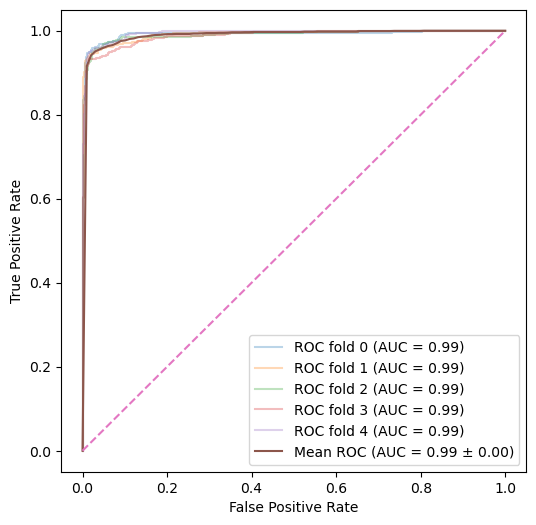

In [196]:
cv_results = cross_validate(
    model_svm, X_train, y_train, cv=cv, return_estimator=True, return_indices=True)

tprs = []
aucs = []
best_thresholds = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(6, 6))

for i, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train)):
    model = cv_results["estimator"][i]
    probas = model.predict_proba(X_train.iloc[test_idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_train.iloc[test_idx], probas)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    aucs.append(auc(fpr, tpr))
    
    fpr, tpr, thresholds = roc_curve(y_train.iloc[test_idx], probas)

    # Calculate Youden's J-Statistic
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]
    best_thresholds.append(best_threshold)

    print(f"Fold {i} Best Threshold: {best_threshold:.4f}")

    plt.plot(fpr, tpr, alpha=0.3, label=f"ROC fold {i} (AUC = {aucs[i]:.2f})")

optimal_threshold = np.mean(best_thresholds)
print(optimal_threshold)
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)
svm_aucs = aucs

plt.plot(mean_fpr, mean_tpr, label=f"Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Fitting the model and predicting...

In [200]:
start = time.time()
model_svm.fit(X_train, y_train)
end = time.time()
print(f"Training time: {end - start:.2f} seconds")


start = time.time()
y_pred_svm = model_svm.predict(X_test)
end = time.time()
print(f"Prediction time: {end - start:.2f} seconds")


Training time: 1.41 seconds
Prediction time: 0.07 seconds


In [201]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1747
           1       0.96      0.94      0.95       603

    accuracy                           0.97      2350
   macro avg       0.97      0.96      0.97      2350
weighted avg       0.97      0.97      0.97      2350



In [202]:
test_probabilities = model_svm.predict_proba(X_test)[:, 1]
y_pred_svm_opt = (test_probabilities >= optimal_threshold).astype(int)

print(classification_report(y_test, y_pred_svm_opt))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1747
           1       0.93      0.95      0.94       603

    accuracy                           0.97      2350
   macro avg       0.96      0.96      0.96      2350
weighted avg       0.97      0.97      0.97      2350



## Comparison Graphs

Now going to create dictionaries which hold the CV results in order to plot blox plots.

In [211]:
accuracy_scores = {'Logistic Regression': results_acc_logreg, 'KNN': results_acc_knn, 
                   'SVM': results_acc_svm, 'Random Forests': results_acc_rf,'Neural Network': results_acc_nn}

precision_scores = {'Logistic Regression': results_pre_logreg, 'KNN': results_pre_knn, 
                   'SVM': results_pre_svm, 'Random Forests': results_pre_rf,'Neural Network': results_pre_nn}


recall_scores = {'Logistic Regression': results_rec_logreg, 'KNN': results_rec_knn, 
                   'SVM': results_rec_svm, 'Random Forests': results_rec_rf,'Neural Network': results_rec_nn}

f1_scores = {'Logistic Regression': results_f1_logreg, 'KNN': results_f1_knn, 
                   'SVM': results_f1_svm, 'Random Forests': results_f1_rf,'Neural Network': results_f1_nn}

auc_results = {'Logistic Regression': logreg_aucs, 'KNN': knn_aucs, 
                   'SVM': svm_aucs, 'Random Forests': rf_aucs,'Neural Network': nn_aucs}

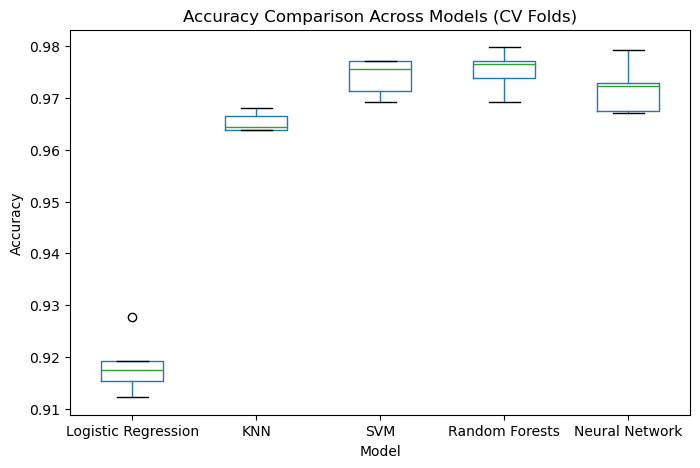

In [213]:
plt.figure(figsize=(8, 5))
pd.DataFrame(accuracy_scores).boxplot(grid = False, )
plt.title(f'Accuracy Comparison Across Models (CV Folds)')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.show()

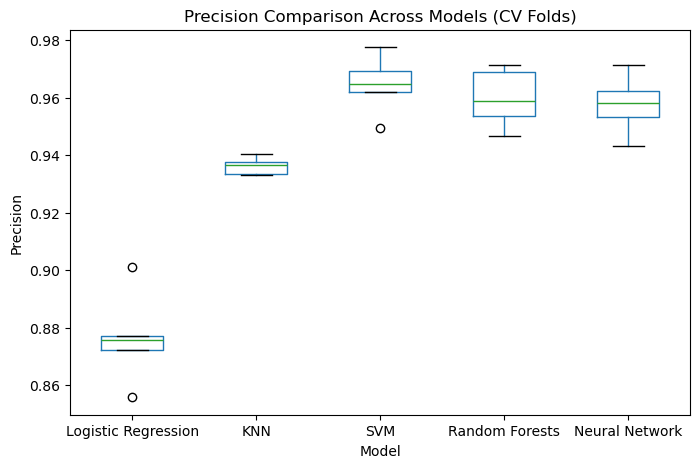

In [215]:
plt.figure(figsize=(8, 5))
pd.DataFrame(precision_scores).boxplot(grid = False, )
plt.title(f'Precision Comparison Across Models (CV Folds)')
plt.ylabel('Precision')
plt.xlabel('Model')
plt.show()

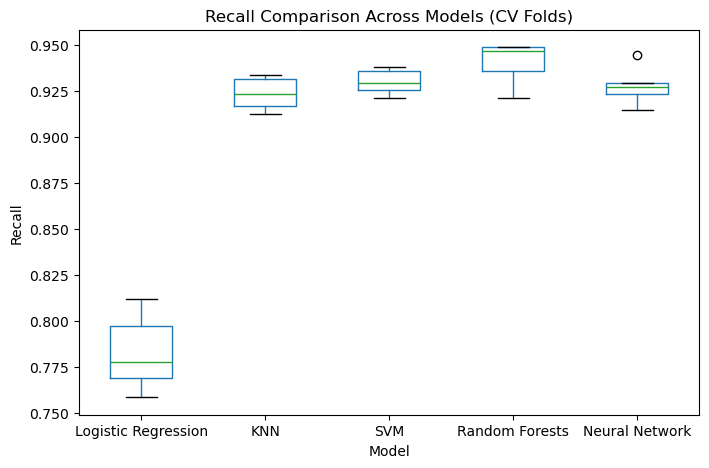

In [217]:
plt.figure(figsize=(8, 5))
pd.DataFrame(recall_scores).boxplot(grid = False, )
plt.title(f'Recall Comparison Across Models (CV Folds)')
plt.ylabel('Recall')
plt.xlabel('Model')
plt.show()

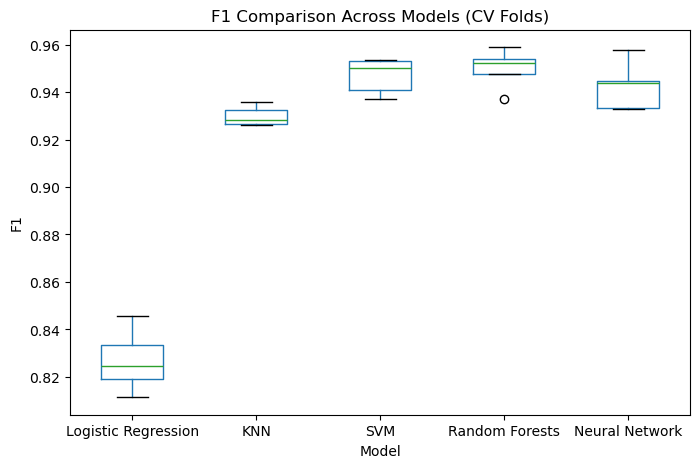

In [219]:
plt.figure(figsize=(8, 5))
pd.DataFrame(f1_scores).boxplot(grid = False, )
plt.title(f'F1 Comparison Across Models (CV Folds)')
plt.ylabel('F1')
plt.xlabel('Model')
plt.show()

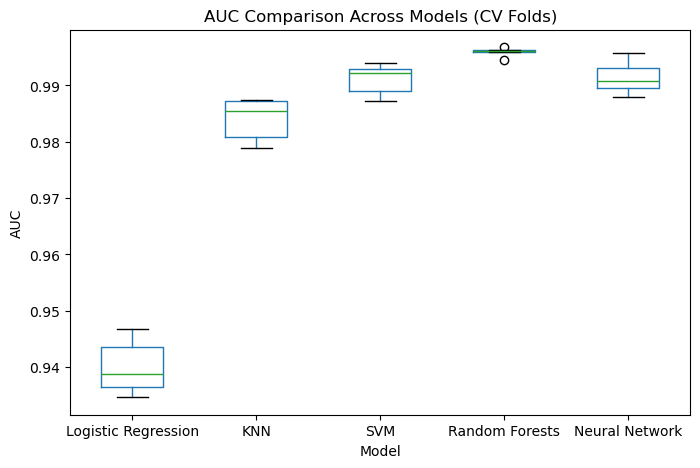

In [221]:
plt.figure(figsize=(8, 5))
pd.DataFrame(auc_results).boxplot(grid = False, )
plt.title(f'AUC Comparison Across Models (CV Folds)')
plt.ylabel('AUC')
plt.xlabel('Model')
plt.show()

Now going to create dictionaries for performance on the holdout test. One for the 0.5 threshold and one for the optimal threshold.

In [224]:
all_scores = {
    'Logistic Regression': {
        'accuracy': accuracy_score(y_test, y_pred_lr),
        'precision': precision_score(y_test, y_pred_lr),
        'recall': recall_score(y_test, y_pred_lr),
        'f1': f1_score(y_test, y_pred_lr),
    },
    'KNN': {
        'accuracy': accuracy_score(y_test, y_pred_knn),
        'precision': precision_score(y_test, y_pred_knn),
        'recall': recall_score(y_test, y_pred_knn),
        'f1': f1_score(y_test, y_pred_knn),
    },
    'SVM': {
        'accuracy': accuracy_score(y_test, y_pred_svm),
        'precision': precision_score(y_test, y_pred_svm),
        'recall': recall_score(y_test, y_pred_svm),
        'f1': f1_score(y_test, y_pred_svm),
    },
    'Random Forests': {
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'precision': precision_score(y_test, y_pred_rf),
        'recall': recall_score(y_test, y_pred_rf),
        'f1': f1_score(y_test, y_pred_rf),
    },
    'Neural Network': {
        'accuracy': accuracy_score(y_test, y_pred_nn),
        'precision': precision_score(y_test, y_pred_nn),
        'recall': recall_score(y_test, y_pred_nn),
        'f1': f1_score(y_test, y_pred_nn),
    }
}

opt_scores = {
    'Logistic Regression': {
        'accuracy': accuracy_score(y_test, y_pred_lr_opt),
        'precision': precision_score(y_test, y_pred_lr_opt),
        'recall': recall_score(y_test, y_pred_lr_opt),
        'f1': f1_score(y_test, y_pred_lr),
    },
    'KNN': {
        'accuracy': accuracy_score(y_test, y_pred_knn_opt),
        'precision': precision_score(y_test, y_pred_knn_opt),
        'recall': recall_score(y_test, y_pred_knn_opt),
        'f1': f1_score(y_test, y_pred_knn_opt),
    },
    'SVM': {
        'accuracy': accuracy_score(y_test, y_pred_svm_opt),
        'precision': precision_score(y_test, y_pred_svm_opt),
        'recall': recall_score(y_test, y_pred_svm_opt),
        'f1': f1_score(y_test, y_pred_svm_opt),
    },
    'Random Forests': {
        'accuracy': accuracy_score(y_test, y_pred_rf_opt),
        'precision': precision_score(y_test, y_pred_rf_opt),
        'recall': recall_score(y_test, y_pred_rf_opt),
        'f1': f1_score(y_test, y_pred_rf_opt),
    },
    'Neural Network': {
        'accuracy': accuracy_score(y_test, y_pred_nn_opt),
        'precision': precision_score(y_test, y_pred_nn_opt),
        'recall': recall_score(y_test, y_pred_nn_opt),
        'f1': f1_score(y_test, y_pred_nn_opt),
    }
}

Now plotting bar graphs for each metric, making the optimal threshold hatched in order to easily distinguish between the two thresholds.

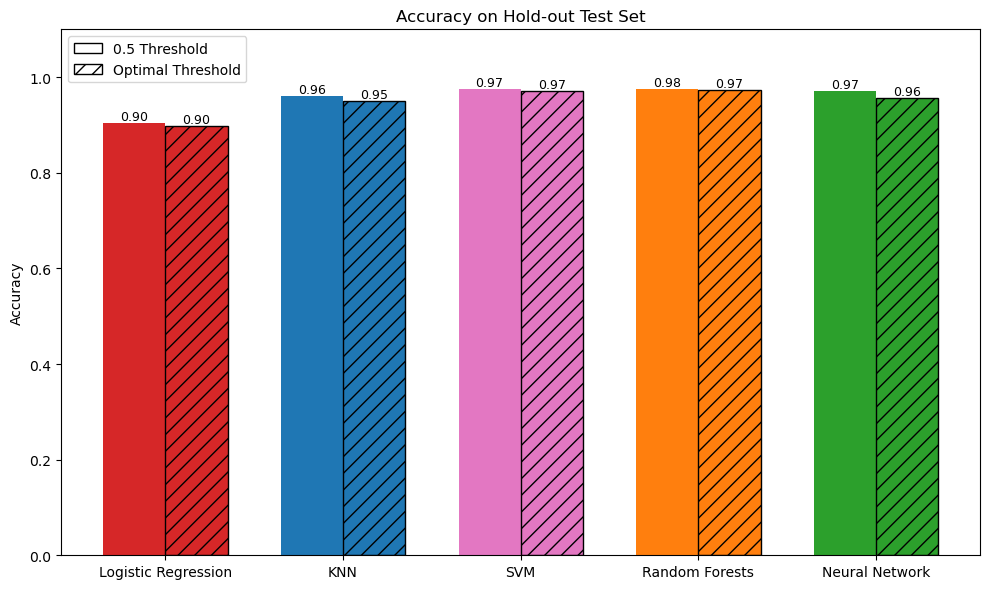

In [227]:
models = list(all_scores.keys())
accuracy_vals = [all_scores[m]['accuracy'] for m in models]
opt_accuracy_vals = [opt_scores[m]['accuracy'] for m in models]  


width = 0.35
x = np.arange(len(models))

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width/2,
    accuracy_vals,
    width, color = ['tab:red', 'tab:blue', 'tab:pink', 'tab:orange', 'tab:green']) 

bars2 = plt.bar(
    x + width/2,
    opt_accuracy_vals,
    width,
    label='Optimal Threshold',
    color = ['tab:red', 'tab:blue', 'tab:pink', 'tab:orange', 'tab:green'],
    edgecolor='black',
    hatch='//'  
)

plt.title('Accuracy on Hold-out Test Set')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.xticks(x, models)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.legend(loc = 'upper left', handles=[
    Patch(facecolor='white', edgecolor='black', label='0.5 Threshold'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='Optimal Threshold')
])
plt.tight_layout()
plt.show()

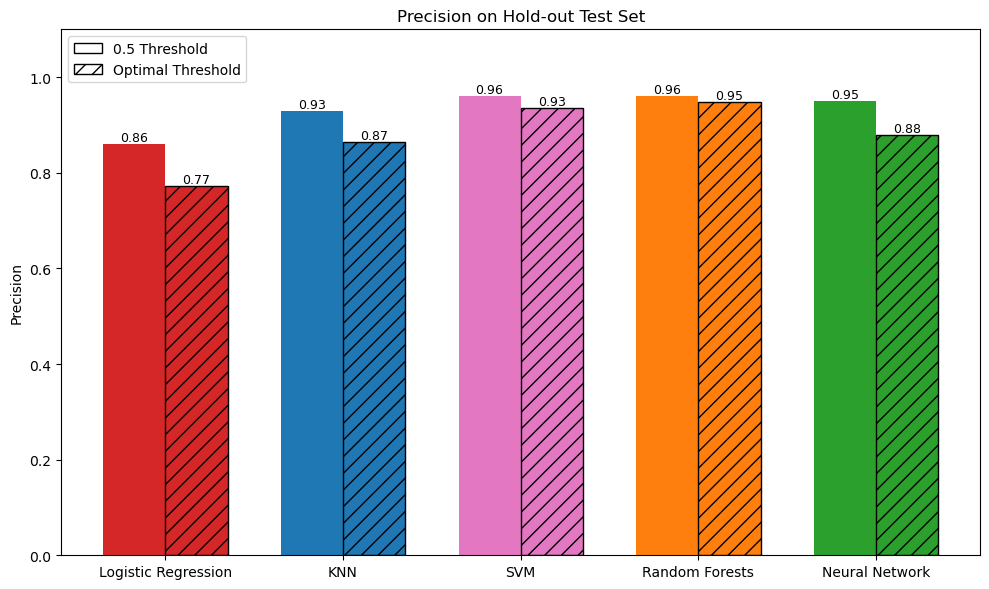

In [229]:
precision_vals = [round(all_scores[model]['precision'], 2) for model in models]
opt_precision_vals = [opt_scores[m]['precision'] for m in models]  


width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width/2,
    precision_vals,
    width, color = ['tab:red', 'tab:blue', 'tab:pink', 'tab:orange', 'tab:green']) 

bars2 = plt.bar(
    x + width/2,
    opt_precision_vals,
    width,
    label='Optimal Threshold',
    color = ['tab:red', 'tab:blue', 'tab:pink', 'tab:orange', 'tab:green'],
    edgecolor='black',
    hatch='//'   
)

plt.title('Precision on Hold-out Test Set')
plt.ylabel('Precision')
plt.ylim(0, 1.1)
plt.xticks(x, models)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.legend(loc = 'upper left' , handles=[
    Patch(facecolor='white', edgecolor='black', label='0.5 Threshold'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='Optimal Threshold')
])
plt.tight_layout()
plt.show()

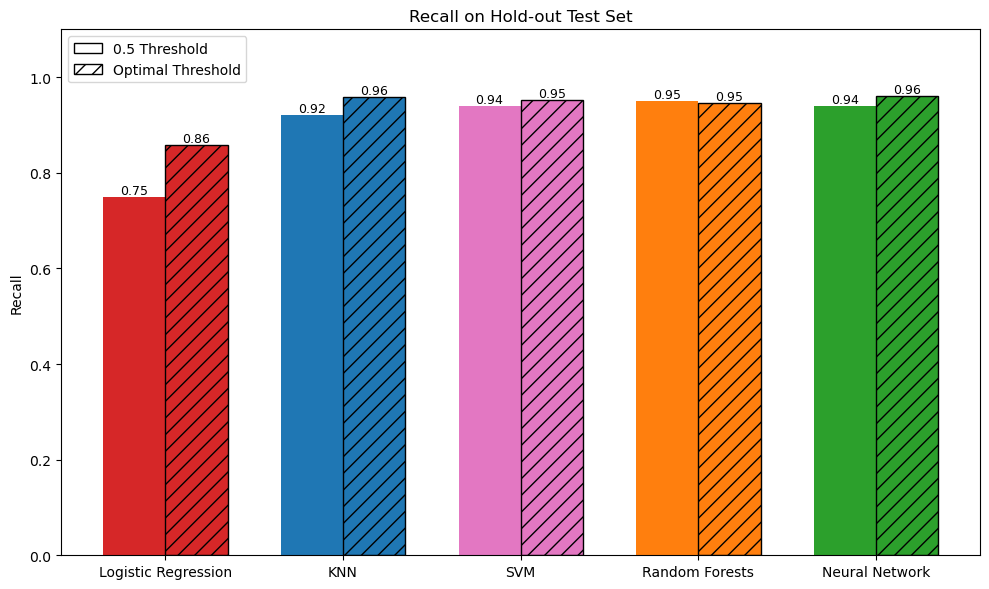

In [231]:
recall_vals = [round(all_scores[model]['recall'], 2) for model in models]
opt_recall_vals = [opt_scores[m]['recall'] for m in models]  


width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width/2,
    recall_vals,
    width, color = ['tab:red', 'tab:blue', 'tab:pink', 'tab:orange', 'tab:green']) 

bars2 = plt.bar(
    x + width/2,
    opt_recall_vals,
    width,
    label='Optimal Threshold',
    color = ['tab:red', 'tab:blue', 'tab:pink', 'tab:orange', 'tab:green'],
    edgecolor='black',
    hatch='//'  
)

plt.title('Recall on Hold-out Test Set')
plt.ylabel('Recall')
plt.ylim(0, 1.1)
plt.xticks(x, models)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.legend(loc = 'upper left',handles=[
    Patch(facecolor='white', edgecolor='black', label='0.5 Threshold'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='Optimal Threshold')
])
plt.tight_layout()
plt.show()

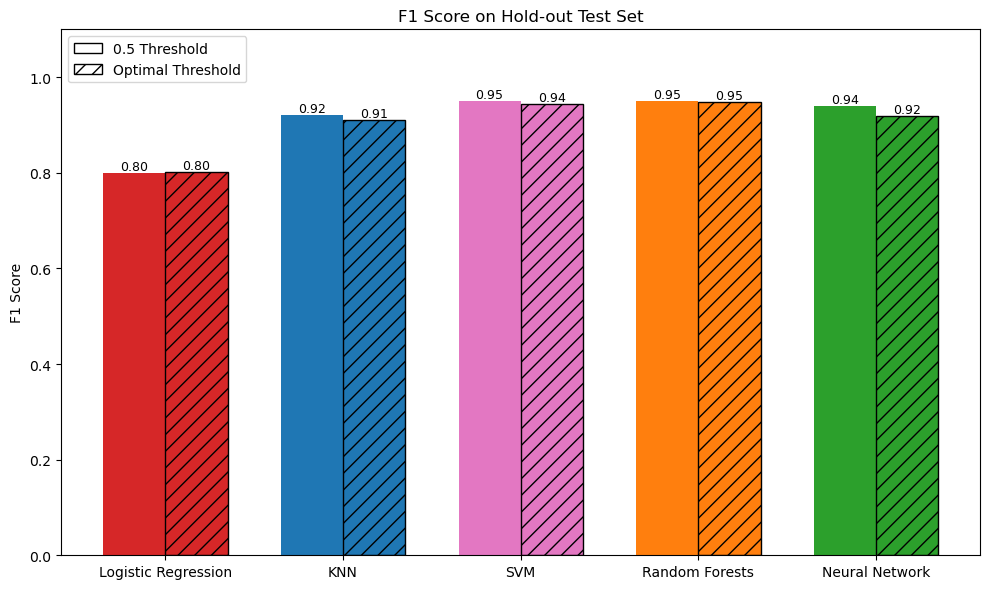

In [233]:
f1_vals = [round(all_scores[model]['f1'], 2) for model in models]
opt_f1_vals = [opt_scores[m]['f1'] for m in models]  


width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width/2,
    f1_vals,
    width, color = ['tab:red', 'tab:blue', 'tab:pink', 'tab:orange', 'tab:green']) 

bars2 = plt.bar(
    x + width/2,
    opt_f1_vals,
    width,
    label='Optimal Threshold',
    color = ['tab:red', 'tab:blue', 'tab:pink', 'tab:orange', 'tab:green'],
    edgecolor='black',
    hatch='//'   
)

plt.title('F1 Score on Hold-out Test Set')
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
plt.xticks(x, models)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.legend(loc = 'upper left' , handles=[
    Patch(facecolor='white', edgecolor='black', label='0.5 Threshold'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='Optimal Threshold')
])
plt.tight_layout()
plt.show()